# S&P 500 Options — Building the Forward-IV Dataset

This notebook constructs a clean options dataset with:
- Implied forward prices extracted from **put-call parity** (model-free, no dividend assumption)
- **Forward moneyness** log(K/F) as the canonical strike coordinate
- **Implied volatility** computed from the Black (1976) forward formula

The output is saved to `output/options_with_forward_iv_clean.csv` and used as input for SSVI calibration.

## A. Imports and setup

In [1]:

import sys
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [ ]:
from pathlib import Path
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
if BASE.name == "notebook":
    BASE = BASE.parent

# Step up to project root if src/ is not directly in cwd
PROJ_ROOT = BASE if (BASE / "src").exists() else BASE.parent

SRC_DIR   = PROJ_ROOT / "src"
OUTPUT_DIR = PROJ_ROOT / "output"
PLOT_DIR  = OUTPUT_DIR / "plots"
CACHE_DIR = OUTPUT_DIR / "cache"
DATA_REPO_DIR = PROJ_ROOT / "Data"   # small CSVs published to GitHub (consumed by S1/S2/A-D)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_REPO_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from cleaning      import clean_options, print_cleaning_report, print_cleaning_summary, filter_forward_moneyness
from forward_curve import (compute_pair_forward, estimate_forward_curve,
                            attach_forward_to_options, flag_forward_nodes, plot_forward_diagnostics)
from black_scholes import add_implied_volatility_forward

print('Imports OK.')
print(f'SRC_DIR:    {SRC_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'DATA_REPO_DIR: {DATA_REPO_DIR}')

## B. Load raw data

In [3]:
RAW_PATH   = PROJ_ROOT / "FullOptionDatasetEngineered.csv"
CACHE_PATH = OUTPUT_DIR / 'options_with_forward_iv_clean.csv'
force_recompute = False   # set True to rebuild even if cache exists

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f'Run notebook 00 first to build: {RAW_PATH}'
    )

df_raw = pd.read_csv(RAW_PATH)
df_raw.columns = df_raw.columns.str.strip()

print(f'Raw dataset: {len(df_raw):,} rows x {len(df_raw.columns)} columns')
print(f'Dates (Time Elapsed): {df_raw["Time Elapsed"].nunique()} unique values')
print(f'  Range: {df_raw["Time Elapsed"].min():.0f} – {df_raw["Time Elapsed"].max():.0f}')
print()
print('Columns:', list(df_raw.columns))
df_raw.head(3)

Raw dataset: 2,324,008 rows x 16 columns
Dates (Time Elapsed): 2769 unique values
  Range: 0 – 4014

Columns: ['Time Elapsed', 'OPT STRIKE PRICE', 'OPEN INTEREST', 'Instrument', 'Mid Price', 'Liquidity Factor', 'OptionType', 'rate3year', 'rate2year', 'rate1year', 'rate6month', 'rate3month', 'rate1month', 'sp500', 'Moneyness', 'TTE']


,Time Elapsed,OPT STRIKE PRICE,OPEN INTEREST,Instrument,Mid Price,Liquidity Factor,OptionType,rate3year,rate2year,rate1year,rate6month,rate3month,rate1month,sp500,Moneyness,TTE
0,0,1100.0,4448.0,SPX06111100C,128.7,0.046620,1,1.66,1.09,0.45,0.18,0.08,0.05,1117.05,-0.015381,1.449315
1,0,1100.0,10141.0,SPX06111100P,115.6,0.051903,-1,1.66,1.09,0.45,0.18,0.08,0.05,1117.05,-0.015381,1.449315
2,0,1100.0,76643.0,SPX12101100C,106.8,0.037453,1,1.66,1.09,0.45,0.18,0.08,0.05,1117.05,-0.015381,0.950685


## C. Pre-forward cleaning

We apply conservative filters *before* estimating the forward:
- Remove options with missing or non-finite data in essential columns
- `Mid Price > 0.05` — removes near-zero, illiquid quotes
- `TTE > 7/365` — removes same-week expiry options (gamma noise)
- `Liquidity Factor <= 0.30` — keeps options with bid-ask spread ≤ 30% of mid
- `Moneyness ∈ [−0.40, 0.30]` — coarse spot-moneyness cut to remove extreme strikes

**Open interest is not filtered**: it remains in the dataset and is used as a weight
in forward estimation and SSVI calibration.

In [4]:
df_clean, report = clean_options(
    df_raw,
    min_mid_price=0.05,
    min_ttm=7/365,
    max_liquidity=0.30,
    min_moneyness=-0.40,
    max_moneyness=0.30,
)

print_cleaning_report(report)
print_cleaning_summary(df_clean)

Step                                                   Before    After   Removed  Removed%  Dates B  Dates A
------------------------------------------------------------------------------------------------------------
Raw data (before filters)                            2,324,008 2,324,008         0      0.0%     2769     2769
NaN / Inf in essential columns                       2,324,008 2,324,008         0      0.0%     2769     2769
Mid Price <= 0.05                                    2,324,008 2,324,008         0      0.0%     2769     2769
TTE <= 0.0192 (7 days)                               2,324,008 2,324,008         0      0.0%     2769     2769
Liquidity Factor > 0.3                               2,324,008 2,324,008         0      0.0%     2769     2769
Moneyness outside [-0.4, 0.3]                        2,324,008 2,324,008         0      0.0%     2769     2769
------------------------------------------------------------------------------------------------------------
TOTAL  

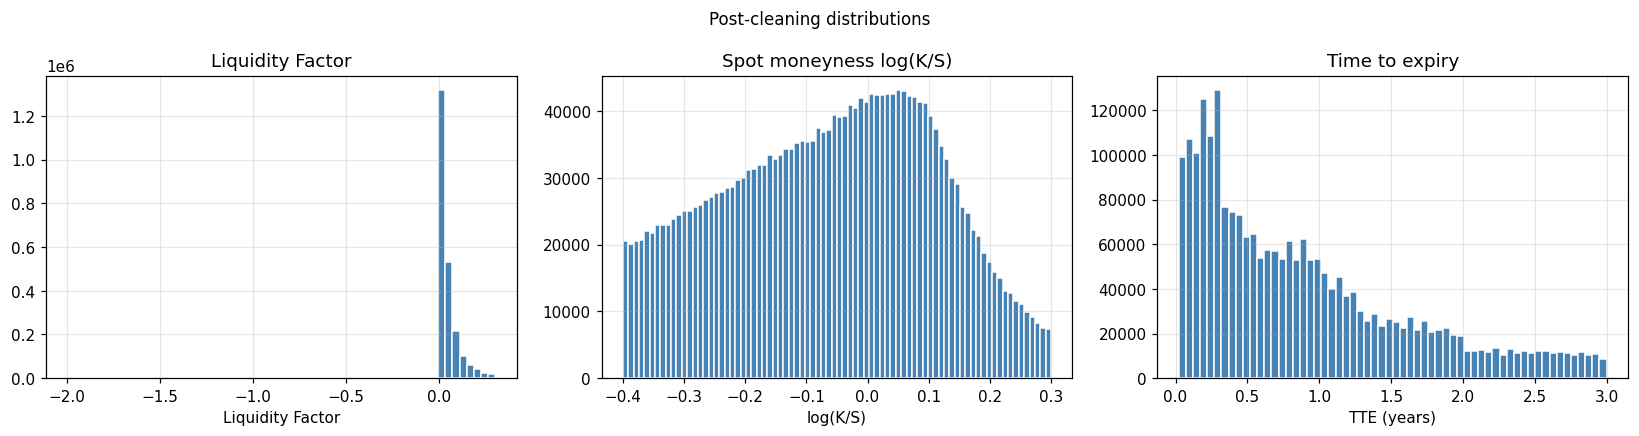

Calls: 1,116,525   Puts: 1,207,483


In [5]:
# Liquidity and moneyness distributions after cleaning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Post-cleaning distributions', fontsize=11)

df_clean['Liquidity Factor'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white', lw=0.3)
axes[0].set_xlabel('Liquidity Factor'); axes[0].set_title('Liquidity Factor')

df_clean['Moneyness'].hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white', lw=0.3)
axes[1].set_xlabel('log(K/S)'); axes[1].set_title('Spot moneyness log(K/S)')

df_clean['TTE'].hist(bins=60, ax=axes[2], color='steelblue', edgecolor='white', lw=0.3)
axes[2].set_xlabel('TTE (years)'); axes[2].set_title('Time to expiry')

plt.tight_layout()
plt.show()

print(f'Calls: {(df_clean["OptionType"]==1).sum():,}   Puts: {(df_clean["OptionType"]==-1).sum():,}')

## D. Forward curve construction

We recover the implied forward $F(t, T)$ from **put-call parity** (no dividend model needed):

$$F = K + e^{rT}(C - P)$$

For each $(\text{date},\, T,\, K)$ triple where both a call and a put exist, we compute one forward estimate.
We then aggregate over near-ATM pairs using an **OI-weighted median** to obtain a robust $F$ per $(\text{date}, T)$ node.

A fuzzy TTE tolerance (`fuzzy_tte_tol=1e-5`) is used to recover pairs where call and put TTE differ
by a sub-day rounding artefact.

In [6]:
t0 = time.time()

# Step 1: matched call/put pairs → one forward per (date, TTE, strike)
pairs = compute_pair_forward(df_clean, fuzzy_tte_tol=1e-5)
print(f'Call/put pairs: {len(pairs):,}')

# Step 2: OI-weighted median forward per (date, TTE)
fc = estimate_forward_curve(pairs, atm_band=0.05)
print(f'Forward curve nodes: {len(fc):,}   '
      f'(dates: {fc["Time Elapsed"].nunique()}, maturities: {fc["TTE"].nunique()})')

# Step 3: attach forward and compute forward_moneyness = log(K/F)
df_fwd = attach_forward_to_options(df_clean, fc)

print(f'\nElapsed: {time.time()-t0:.1f}s')

Call/put pairs: 1,057,454
Forward curve nodes: 28,696   (dates: 2768, maturities: 776)
Forward attached: 100.0% of rows have a valid forward.

Elapsed: 80.0s


In [7]:
# Step 4: flag and inspect forward curve quality
fc_flagged = flag_forward_nodes(fc, df_clean, min_pairs=5, max_std=5.0)

print(f'\nForward / spot ratio statistics:')
print(fc_flagged['ratio'].describe().round(4).to_string())

print(f'\nn_pairs per node:')
print(fc_flagged['n_pairs'].describe().round(1).to_string())

Forward curve: 2422/28696 nodes flagged (8.4%) — 2413 low-pair, 9 high-std.

Forward / spot ratio statistics:
count    28696.0000
mean         1.0003
std          0.0090
min          0.9586
25%          0.9971
50%          1.0013
75%          1.0060
max          1.0278

n_pairs per node:
count    28696.0
mean         8.3
std          2.9
min          1.0
25%          6.0
50%          8.0
75%         11.0
max         22.0


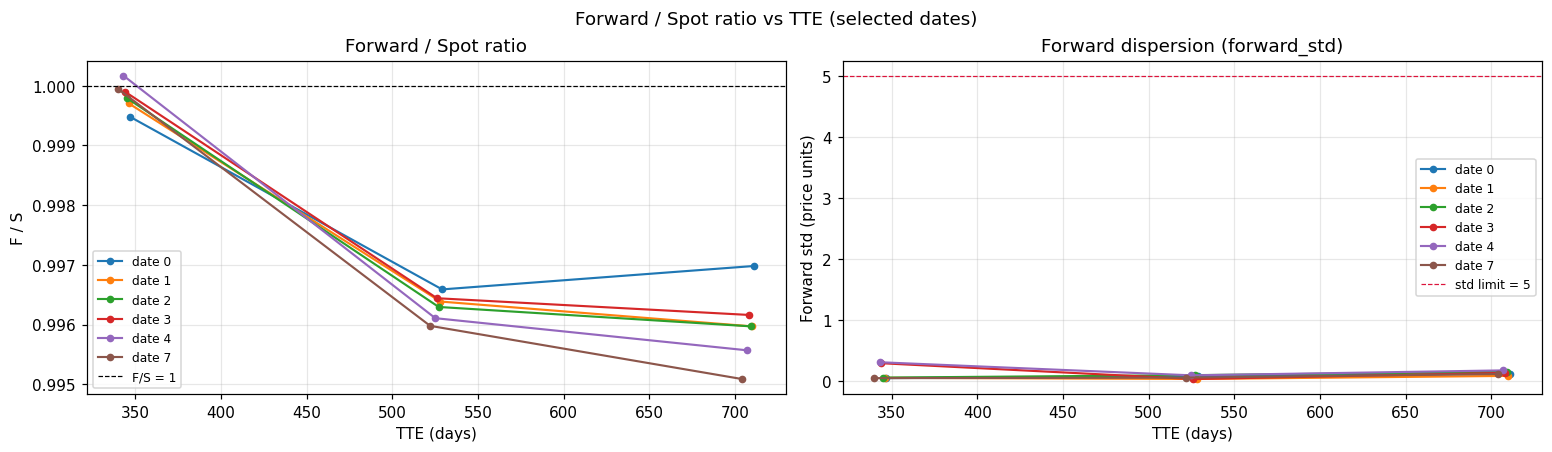

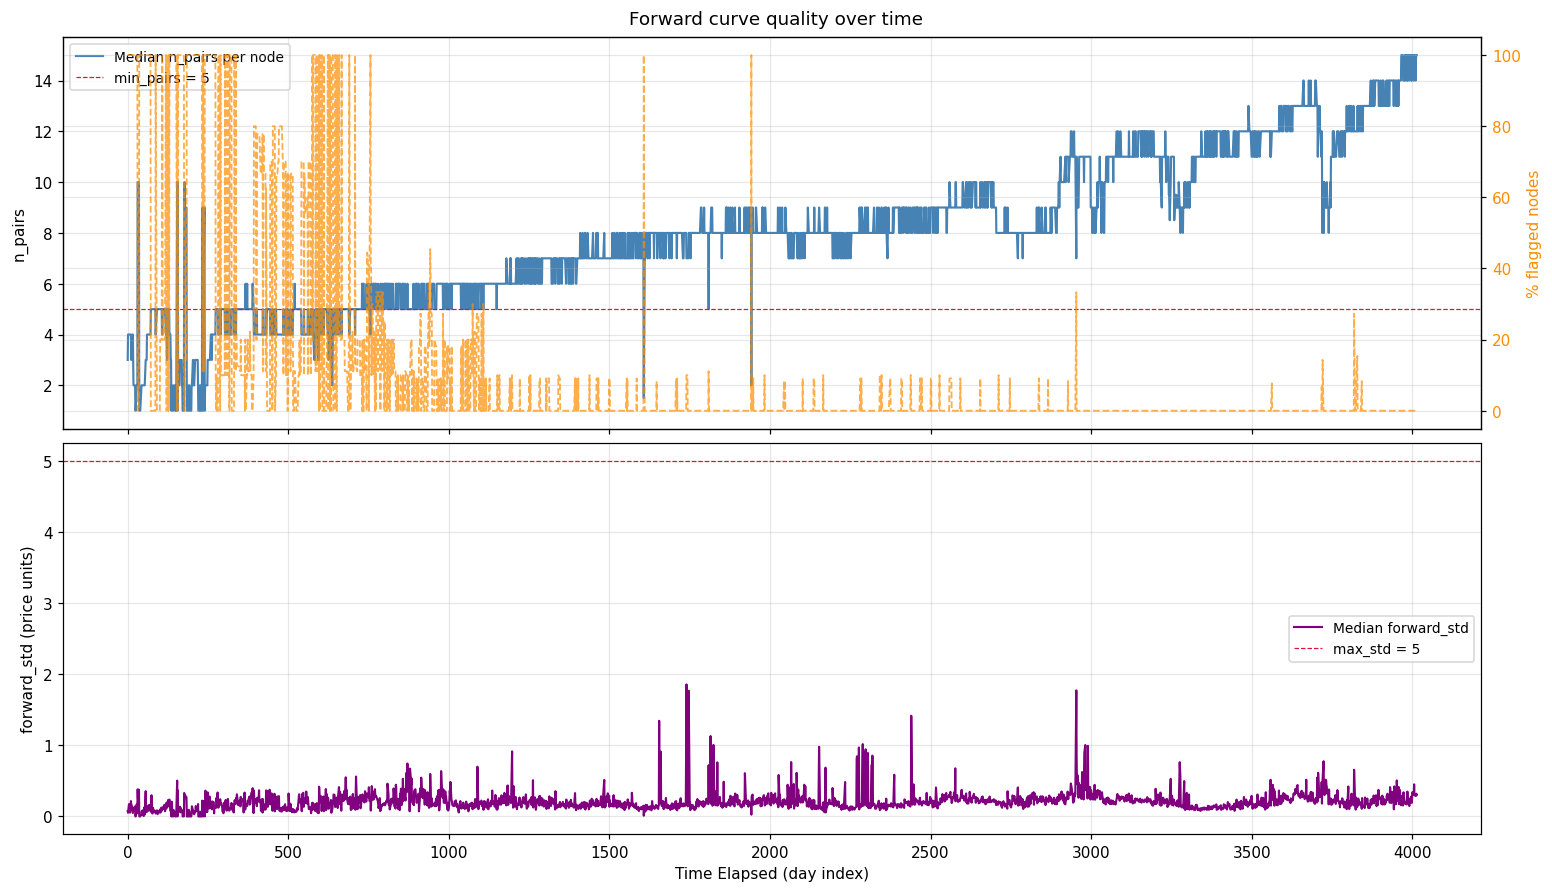

In [8]:
# Diagnostic plots
plot_forward_diagnostics(fc_flagged, sample_dates=sorted(fc['Time Elapsed'].unique())[:6])

## E. Forward moneyness domain

We filter on `forward_moneyness = log(K/F)` to define the final calibration domain:

| Bound | Value | Rationale |
|-------|-------|----------|
| Left  | −0.30 | Deep OTM puts: good liquidity, anchor the left wing |
| Right | +0.20 | Deep OTM calls are sparse and noisy — SSVI fits poorly above +0.20 |

The **asymmetric domain** reflects the empirical structure of the SPX smile:
the left wing carries most of the information (puts = crash protection, high OI),
while the right wing is thinner and less informative.

In [9]:
report_fwd = []

n_before = len(df_fwd)
calls_b  = (df_fwd['OptionType'] == 1).sum()
puts_b   = (df_fwd['OptionType'] == -1).sum()

df_domain = filter_forward_moneyness(df_fwd, report_fwd, min_forward_moneyness=-0.30, max_forward_moneyness=0.20)

n_after  = len(df_domain)
calls_a  = (df_domain['OptionType'] == 1).sum()
puts_a   = (df_domain['OptionType'] == -1).sum()
otm_c    = ((df_domain['OptionType'] == 1) & (df_domain['forward_moneyness'] < 0)).sum()
right_w  = ((df_domain['OptionType'] == 1) & (df_domain['forward_moneyness'] >= 0)).sum()

print(f'Before domain filter: {n_before:>8,}   calls {calls_b:,}   puts {puts_b:,}')
print(f'After  domain filter: {n_after:>8,}   calls {calls_a:,}   puts {puts_a:,}')
print(f'  OTM calls (k<0)   : {otm_c:,}')
print(f'  Right wing (k>=0) : {right_w:,}')
print(f'  Retained: {100*n_after/n_before:.1f}%')

Before domain filter: 2,324,008   calls 1,116,525   puts 1,207,483
After  domain filter: 1,934,984   calls 939,039   puts 995,945
  OTM calls (k<0)   : 583,391
  Right wing (k>=0) : 355,648
  Retained: 83.3%


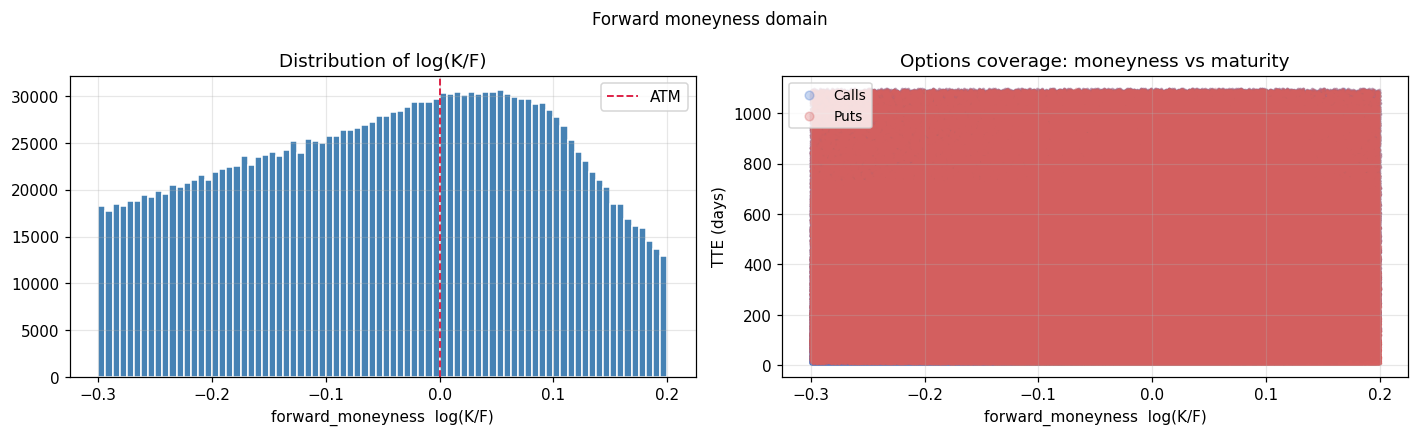

In [10]:
# Forward moneyness distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Forward moneyness domain', fontsize=11)

df_domain['forward_moneyness'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white', lw=0.2)
axes[0].axvline(0, color='crimson', lw=1.2, ls='--', label='ATM')
axes[0].set_xlabel('forward_moneyness  log(K/F)')
axes[0].set_title('Distribution of log(K/F)')
axes[0].legend()

calls = df_domain[df_domain['OptionType'] == 1]
puts  = df_domain[df_domain['OptionType'] == -1]
axes[1].scatter(calls['forward_moneyness'], calls['TTE']*365, s=2, alpha=0.3,
                color='#4878CF', label='Calls')
axes[1].scatter(puts['forward_moneyness'],  puts['TTE']*365,  s=2, alpha=0.3,
                color='#D65F5F', label='Puts')
axes[1].set_xlabel('forward_moneyness  log(K/F)')
axes[1].set_ylabel('TTE (days)')
axes[1].set_title('Options coverage: moneyness vs maturity')
axes[1].legend(fontsize=9, markerscale=4)

plt.tight_layout()
plt.show()

## F. Forward implied volatility

We compute `implied_vol_forward` by inverting the Black (1976) formula:

$$C = e^{-rT}\bigl[F N(d_1) - K N(d_2)\bigr], \quad d_1 = \frac{\log(F/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

Rows where inversion fails (price below intrinsic, or no root found) are dropped.
We cache the result to avoid recomputing on re-runs.

In [ ]:
if os.path.exists(CACHE_PATH) and not force_recompute:
    print(f'Loading cache: {CACHE_PATH}')
    df_iv = pd.read_csv(CACHE_PATH)
    print(f'Loaded {len(df_iv):,} rows.')
else:
    print('Computing implied_vol_forward (may take a few minutes)...')
    t0 = time.time()
    df_iv = add_implied_volatility_forward(
        df_domain,
        min_iv=0.03,
        max_iv=2.0,
    )
    elapsed = time.time() - t0
    print(f'Done in {elapsed:.0f}s — {len(df_iv):,} rows retained.')
    df_iv.to_csv(CACHE_PATH, index=False)
    print(f'Saved: {CACHE_PATH}')

    DATA_IV_PATH = DATA_REPO_DIR / CACHE_PATH.name
    df_iv.to_csv(DATA_IV_PATH, index=False)
    print(f'Saved (repo Data/ copy — used by notebook A): {DATA_IV_PATH}')

In [12]:
# IV summary statistics
print('implied_vol_forward statistics:')
print(df_iv['implied_vol_forward'].describe().round(4).to_string())

# ATM call/put IV gap (should be ~0 by put-call parity)
atm_mask  = df_iv['forward_moneyness'].abs() < 0.02
atm_calls = df_iv[atm_mask & (df_iv['OptionType'] == 1)]['implied_vol_forward']
atm_puts  = df_iv[atm_mask & (df_iv['OptionType'] == -1)]['implied_vol_forward']
print(f'\nATM (|k|<0.02) median IV:')
print(f'  Calls: {atm_calls.median():.4f}   Puts: {atm_puts.median():.4f}   '
      f'Gap: {abs(atm_calls.median()-atm_puts.median()):.4f}')

implied_vol_forward statistics:
count    1.500012e+06
mean     1.956000e-01
std      6.920000e-02
min      3.590000e-02
25%      1.501000e-01
50%      1.873000e-01
75%      2.271000e-01
max      1.321300e+00

ATM (|k|<0.02) median IV:
  Calls: 0.1618   Puts: 0.1616   Gap: 0.0002


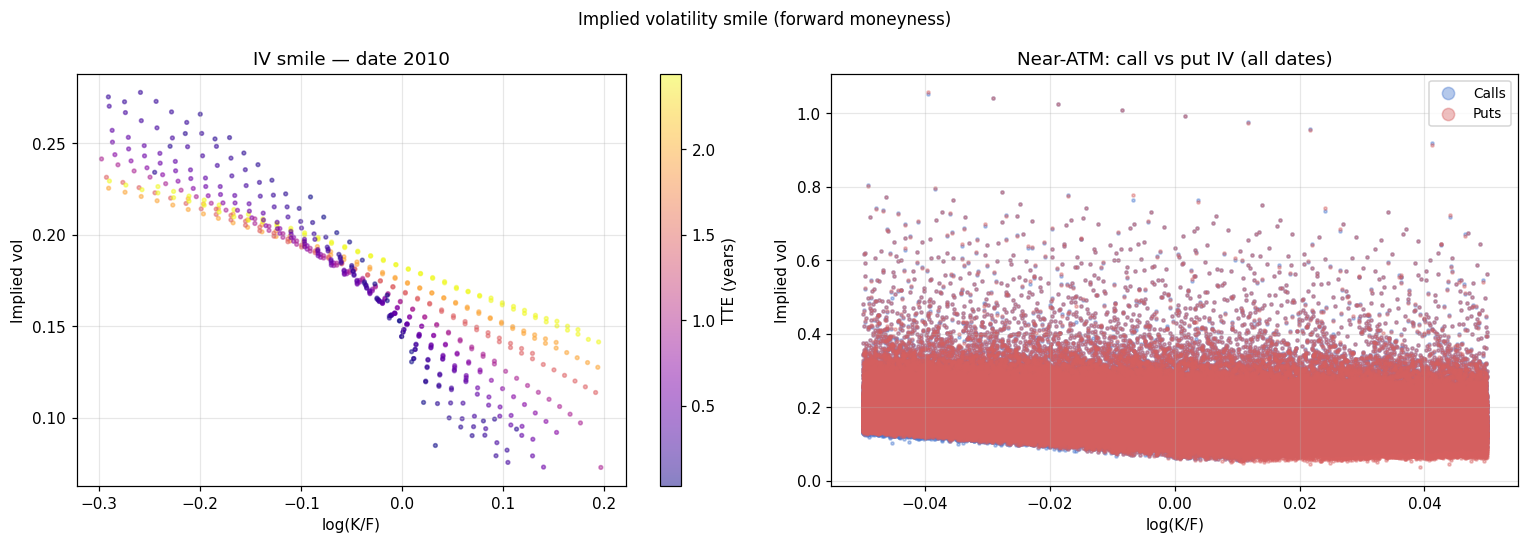

In [13]:
# IV smile: scatter plot coloured by TTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Implied volatility smile (forward moneyness)', fontsize=11)

sample_te = sorted(df_iv['Time Elapsed'].unique())[len(df_iv['Time Elapsed'].unique())//2]
sl = df_iv[df_iv['Time Elapsed'] == sample_te]

calls = sl[sl['OptionType'] == 1]
puts  = sl[sl['OptionType'] == -1]

tte_norm = (sl['TTE'] - sl['TTE'].min()) / (sl['TTE'].max() - sl['TTE'].min() + 1e-9)
sc = axes[0].scatter(sl['forward_moneyness'], sl['implied_vol_forward'],
                     c=sl['TTE'], cmap='plasma', s=6, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label='TTE (years)')
axes[0].set_xlabel('log(K/F)'); axes[0].set_ylabel('Implied vol')
axes[0].set_title(f'IV smile — date {sample_te}')

# Call/put comparison near ATM
atm = df_iv[df_iv['forward_moneyness'].abs() < 0.05]
axes[1].scatter(atm[atm['OptionType']==1]['forward_moneyness'],
                atm[atm['OptionType']==1]['implied_vol_forward'],
                s=4, alpha=0.4, color='#4878CF', label='Calls')
axes[1].scatter(atm[atm['OptionType']==-1]['forward_moneyness'],
                atm[atm['OptionType']==-1]['implied_vol_forward'],
                s=4, alpha=0.4, color='#D65F5F', label='Puts')
axes[1].set_xlabel('log(K/F)'); axes[1].set_ylabel('Implied vol')
axes[1].set_title('Near-ATM: call vs put IV (all dates)')
axes[1].legend(fontsize=9, markerscale=4)

plt.tight_layout(); plt.show()

## G. Save final dataset

In [14]:
# Final dataset is already saved inside the cache block above.
# Optionally save as parquet for faster loading:
# df_iv.to_parquet(CACHE_PATH.replace('.csv', '.parquet'), index=False)

print('=== Pipeline summary ===')
print(f'  Raw rows            : {len(df_raw):>8,}')
print(f'  After pre-cleaning  : {len(df_clean):>8,}   ({100*len(df_clean)/len(df_raw):.1f}%)')
print(f'  After forward attach: {len(df_fwd):>8,}')
print(f'  After domain filter : {len(df_domain):>8,}')
print(f'  After IV computation: {len(df_iv):>8,}   ({100*len(df_iv)/len(df_raw):.1f}% of raw)')
print(f'  Unique dates        : {df_iv["Time Elapsed"].nunique()}')
print(f'  Output: {CACHE_PATH}')

print(f'\nFinal columns: {list(df_iv.columns)}')

=== Pipeline summary ===
  Raw rows            : 2,324,008
  After pre-cleaning  : 2,324,008   (100.0%)
  After forward attach: 2,324,008
  After domain filter : 1,934,984
  After IV computation: 1,500,012   (64.5% of raw)
  Unique dates        : 2768
  Output: C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO_FINAL\output\options_with_forward_iv_clean.csv

Final columns: ['Time Elapsed', 'OPT STRIKE PRICE', 'OPEN INTEREST', 'Instrument', 'Mid Price', 'Liquidity Factor', 'OptionType', 'rate3year', 'rate2year', 'rate1year', 'rate6month', 'rate3month', 'rate1month', 'sp500', 'Moneyness', 'TTE', 'forward', 'forward_moneyness', 'implied_vol_forward']
